# FMATCH 8/10 — Camera segmentation → Camera Cloud Fraction (CF-CAM)

**PR topic**: `camera_segmentation.py` — turning each Libera WFOV camera image into
**pseudo-footprints**: radiometer-footprint-sized pixel blocks that let the
camera-timescale FMATCH products (`*-CAMTIME`) reuse the whole footprint pipeline
built in the previous PRs.

For every `CAMERA_TIME` image, `segment_l1b_camera`:

1. tiles the pixel grid into blocks sized to the radiometer footprint diameter
   (`TARGET_FOOTPRINT_DIAMETER_KM` ≈ 2·h·tan(FOV), estimated from the image's own
   [ground sample distance](https://en.wikipedia.org/wiki/Ground_sample_distance));
2. picks each block's **center pixel** as the boresight stand-in (substituting the
   nearest valid pixel and flagging it when the geometric center is fill);
3. reduces the block to one `PseudoFootprint` record — center geolocation/angles,
   pixel-slice provenance, quality flags, and a geographic `BoundingBox` from the
   block's corner pixels (pole/dateline aware).

**Efficiency note (folded into this PR)**: the per-block corner [geodesics](https://en.wikipedia.org/wiki/Geodesics_on_an_ellipsoid) are the
dominant cost, so they are deferred and computed for *every block of every image* in
one batched [pyproj `Geod`](https://pyproj4.github.io/pyproj/stable/api/geod.html) call (`bounding_box_from_points_batch`) instead of block by block.

**Also in this notebook (sections 4–6)**: the same segmentation is the engine of the
placeholder **Camera Cloud Fraction** algorithms, `libera_utils.cloud_fraction`. We
review **CF-CAM-CAMTIME** (camera timescale, built from these pseudo-footprints) and
**CF-CAM** (radiometer timescale) — the products that feed the FMATCH-CAM algorithms'
`cloud_fraction_camera` input. The pseudo-footprint is *created* in CF-CAM-CAMTIME, not
in footprint matching.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from libera_utils.footprint_matching import camera_segmentation as seg

print(f"target footprint diameter: {seg.TARGET_FOOTPRINT_DIAMETER_KM:.1f} km")

target footprint diameter: 29.1 km


## Setup: a synthetic L1B camera image

One 48×48-pixel image at ~0.06° (~6.7 km) ground sample distance, so a
radiometer-sized block spans roughly 4×4 pixels. A corner of the image is filled
with invalid geolocation to show the quality-flag handling.

In [3]:
n_pix = 48
base_lat, base_lon = 35.0, -110.0
step = 0.06
xs = np.arange(n_pix) * step
lat2d = base_lat + np.broadcast_to(xs[:, None], (n_pix, n_pix))
lon2d = base_lon + np.broadcast_to(xs[None, :], (n_pix, n_pix))

fill = -999.0
lat2d = lat2d.copy()
lon2d = lon2d.copy()
lat2d[:6, :6] = fill  # a dead corner (e.g. off-Earth or failed geolocation)
lon2d[:6, :6] = fill

dims = (seg.CAMERA_TIME_NAME, seg.PIXEL_X_DIM, seg.PIXEL_Y_DIM)
shape = (1, n_pix, n_pix)
dataset = xr.Dataset(
    {
        seg.LATITUDE_NAME: (dims, lat2d[None], {"_FillValue": fill}),
        seg.LONGITUDE_NAME: (dims, lon2d[None], {"_FillValue": fill}),
        seg.ALTITUDE_NAME: (dims, np.full(shape, 500.0)),
        seg.SOLAR_ZENITH_NAME: (dims, np.full(shape, 42.0)),
        seg.VIEWING_ZENITH_NAME: (dims, np.hypot(*np.meshgrid(xs - xs.mean(), xs - xs.mean()))[None] * 8.0),
        seg.RELATIVE_AZIMUTH_NAME: (dims, np.full(shape, 120.0)),
    },
    coords={seg.CAMERA_TIME_NAME: np.array([np.datetime64("2026-06-11T12:00:00", "ns")])},
)

footprints = seg.segment_l1b_camera(dataset)
print(f"{len(footprints)} pseudo-footprints from one {n_pix}x{n_pix} image")

99 pseudo-footprints from one 48x48 image


## 1. The segmentation grid

Each rectangle below is one pseudo-footprint's pixel block (`slice_x`/`slice_y`
provenance); the dot is its center pixel (the boresight stand-in). Blocks whose
center needed nearest-valid substitution or that contain fill pixels carry
quality flags instead of being dropped.

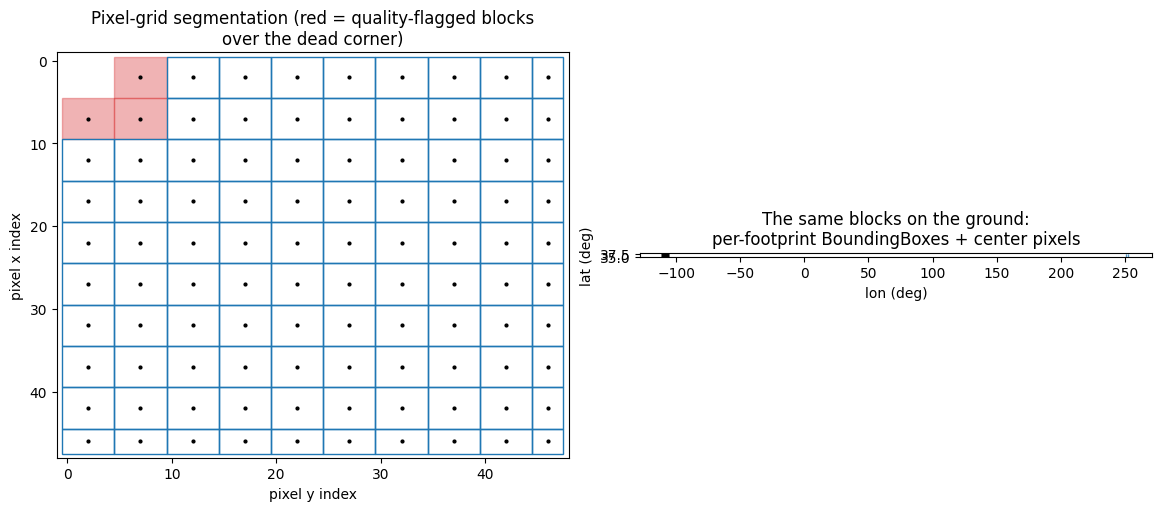

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 5), constrained_layout=True)
for fp in footprints:
    flagged = int(fp.q_flags) != 0
    rect = plt.Rectangle(
        (fp.slice_y.start - 0.5, fp.slice_x.start - 0.5),
        fp.slice_y.stop - fp.slice_y.start,
        fp.slice_x.stop - fp.slice_x.start,
        fill=flagged,
        facecolor="tab:red",
        alpha=0.35 if flagged else 1.0,
        edgecolor="tab:red" if flagged else "tab:blue",
        lw=1.0,
    )
    ax1.add_patch(rect)
    ax1.plot(fp.center_iy, fp.center_ix, ".", color="k", ms=4)
ax1.set_xlim(-1, n_pix)
ax1.set_ylim(n_pix, -1)
ax1.set_xlabel("pixel y index")
ax1.set_ylabel("pixel x index")
ax1.set_title("Pixel-grid segmentation (red = quality-flagged blocks\nover the dead corner)")

for fp in footprints:
    box = fp.bbox
    flagged = int(fp.q_flags) != 0
    ax2.add_patch(
        plt.Rectangle(
            (box.lon_min, box.lat_min),
            box.lon_max - box.lon_min,
            box.lat_max - box.lat_min,
            fill=False,
            ec="tab:red" if flagged else "tab:blue",
            lw=0.9,
        )
    )
    ax2.plot(fp.longitude, fp.latitude, "k.", ms=3)
ax2.set_xlabel("lon (deg)")
ax2.set_ylabel("lat (deg)")
ax2.set_title("The same blocks on the ground:\nper-footprint BoundingBoxes + center pixels")
ax2.set_aspect("equal")
plt.show()

## 2. What one pseudo-footprint carries

In [5]:
fp = footprints[len(footprints) // 2]
print(f"time                    {fp.time}")
print(f"pixel block             x[{fp.slice_x.start}:{fp.slice_x.stop}]  y[{fp.slice_y.start}:{fp.slice_y.stop}]")
print(f"center pixel            ({fp.center_ix}, {fp.center_iy})")
print(f"center geolocation      ({fp.latitude:.3f}, {fp.longitude:.3f}) deg, alt {fp.altitude:.0f} m")
print(
    f"angles (sza/vza/raa)    {fp.solar_zenith_angle:.1f} / {fp.viewing_zenith_angle:.1f} / {fp.relative_azimuth_angle:.1f} deg"
)
print(
    f"bbox                    lat [{fp.bbox.lat_min:.3f}, {fp.bbox.lat_max:.3f}]  lon [{fp.bbox.lon_min:.3f}, {fp.bbox.lon_max:.3f}]"
)
print(f"quality flags           {fp.q_flags!r}")

time                    2026-06-11T12:00:00.000000000
pixel block             x[25:30]  y[0:5]
center pixel            (27, 2)
center geolocation      (36.620, -109.880) deg, alt 500 m
angles (sza/vza/raa)    42.0 / 10.5 / 120.0 deg
bbox                    lat [36.500, 36.740]  lon [-110.000, -109.760]
quality flags           <CameraFootprintQualityFlag: 0>


## 3. Into the camera-timescale product

These pseudo-footprints are exactly what the camtime assembly path of `product.py`
(previous PR) consumes: the ragged per-image segmentation is scattered onto a
rectangular **`(CAMERA_TIME, PSEUDOFOOTPRINT)` grid** — `CAMERA_TIME` is the unique,
sorted image-acquisition axis and `PSEUDOFOOTPRINT` is the 0-based subsection index
within each image. Each block's inclusive pixel extent is carried as the four
`camera_pixel_{x,y}_{min,max}` provenance coordinates. The same `bbox` drives the tile
manager and PSF weighting, so ancillary aggregation works identically on camera
pseudo-footprints and radiometer footprints.

In [6]:
from libera_utils.footprint_matching.product import assemble_fmatch_dataset
from libera_utils.footprint_matching.types import OperationalMode

ds = assemble_fmatch_dataset(
    OperationalMode.CAM_CAMTIME,
    footprints,
    cloud_fraction_camera=np.random.default_rng(3).uniform(0, 100, len(footprints)).astype(np.float32),
    algorithm_version="0.0.0-demo",
    input_files="synthetic",
)
print(f"FMATCH-CAM-CAMTIME dataset: dims={dict(ds.sizes)}")
print(
    f"CAMERA_TIME unique values: {len(np.unique(ds.CAMERA_TIME.values))} (one per image), "
    f"PSEUDOFOOTPRINT records/image: {ds.sizes['PSEUDOFOOTPRINT']}"
)

FMATCH-CAM-CAMTIME dataset: dims={'CAMERA_TIME': 1, 'PSEUDOFOOTPRINT': 99}
CAMERA_TIME unique values: 1 (one per image), PSEUDOFOOTPRINT records/image: 99


## 4. From segmentation to CF-CAM-CAMTIME

The **camera-timescale Camera Cloud Fraction** product, `CF-CAM-CAMTIME`, is produced
by `libera_utils.cloud_fraction` *directly from an L1B CAM file* using this exact
segmentation. `generate_placeholder_cloud_fraction_camtime` reuses the same
`build_camtime_grid` / `build_camtime_provenance` helpers the FMATCH camtime assembly
uses, so the two products share an **identical** `(CAMERA_TIME, PSEUDOFOOTPRINT)` grid
and `camera_pixel_{x,y}_{min,max}` provenance — they align record-for-record. It then
draws a placeholder `cloud_fraction` and `cloud_fraction_standard_deviation` per
pseudo-footprint (percent, reproducible), which FMATCH-CAM-CAMTIME ingests as its
`cloud_fraction_camera` input.

> The values are a **placeholder** (random, in-range) pending the real Libera WFOV
> cloud-fraction retrieval; the record axis and pixel provenance are real.

CF-CAM-CAMTIME variables: ['CAMERA_TIME', 'PSEUDOFOOTPRINT', 'camera_pixel_x_max', 'camera_pixel_x_min', 'camera_pixel_y_max', 'camera_pixel_y_min', 'cloud_fraction', 'cloud_fraction_standard_deviation']
cloud_fraction grid shape (CAMERA_TIME, PSEUDOFOOTPRINT): (1, 99)
cloud_fraction range: [0.1, 98.4] percent

Provenance matches FMATCH-CAM-CAMTIME record-for-record ✔  (CAMERA_TIME, PSEUDOFOOTPRINT, camera_pixel_*)


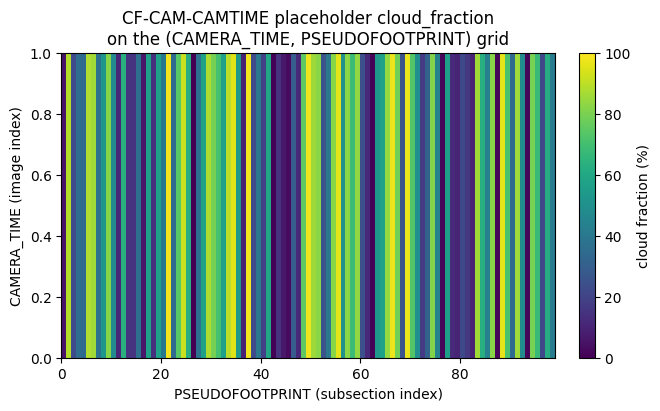

In [7]:
from libera_utils.cloud_fraction.cf_cam_camtime import PRODUCT_DEFINITION_PATH as CF_CAMTIME_DEF
from libera_utils.cloud_fraction.cloud_fraction import generate_placeholder_cloud_fraction_camtime
from libera_utils.io.product_definition import LiberaDataProductDefinition

cf_camtime_definition = LiberaDataProductDefinition.from_yaml(CF_CAMTIME_DEF)
cf_camtime = generate_placeholder_cloud_fraction_camtime(footprints, cf_camtime_definition)

print("CF-CAM-CAMTIME variables:", sorted(cf_camtime))
print(f"cloud_fraction grid shape (CAMERA_TIME, PSEUDOFOOTPRINT): {cf_camtime['cloud_fraction'].shape}")
print(
    f"cloud_fraction range: [{np.nanmin(cf_camtime['cloud_fraction']):.1f}, "
    f"{np.nanmax(cf_camtime['cloud_fraction']):.1f}] percent"
)

# The provenance is byte-for-byte the FMATCH-CAM-CAMTIME grid built from the same footprints.
for name in ("CAMERA_TIME", "PSEUDOFOOTPRINT", "camera_pixel_x_min", "camera_pixel_x_max",
             "camera_pixel_y_min", "camera_pixel_y_max"):
    np.testing.assert_array_equal(np.asarray(cf_camtime[name]), ds[name].to_numpy())
print("\nProvenance matches FMATCH-CAM-CAMTIME record-for-record ✔  (CAMERA_TIME, PSEUDOFOOTPRINT, camera_pixel_*)")

fig, ax = plt.subplots(figsize=(6.5, 4), constrained_layout=True)
mesh = ax.pcolormesh(cf_camtime["cloud_fraction"], cmap="viridis", vmin=0, vmax=100)
ax.set_xlabel("PSEUDOFOOTPRINT (subsection index)")
ax.set_ylabel("CAMERA_TIME (image index)")
ax.set_title("CF-CAM-CAMTIME placeholder cloud_fraction\non the (CAMERA_TIME, PSEUDOFOOTPRINT) grid")
fig.colorbar(mesh, ax=ax, label="cloud fraction (%)")
plt.show()

## 5. CF-CAM (radiometer timescale)

`CF-CAM` is the non-camtime sibling and the mirror of `FMATCH-CAM`: it reads an
**L1B RAD-4CH** file and emits one placeholder `cloud_fraction` /
`cloud_fraction_standard_deviation` per `RADIOMETER_TIME` footprint — the radiometer's
own footprints, so **no camera segmentation** is involved. It feeds `FMATCH-CAM`'s
`cloud_fraction_camera` input, aligned 1:1 by `RADIOMETER_TIME`.

In [8]:
from libera_utils.cloud_fraction.cloud_fraction import generate_placeholder_cloud_fraction_radiometer

# A synthetic RADIOMETER_TIME axis (100 Hz), standing in for what load_l1b_radiometer_inputs returns.
radiometer_time = np.datetime64("2026-06-11T00:00:00", "ns") + np.arange(12, dtype="int64") * np.timedelta64(
    10_000_000, "ns"
)
cf_cam = generate_placeholder_cloud_fraction_radiometer(radiometer_time)

print("CF-CAM variables:", sorted(cf_cam))
print(f"records (RADIOMETER_TIME): {cf_cam['cloud_fraction'].shape[0]}  (1-D, one value per footprint)")
print("first 5 cloud_fraction (%):     ", np.round(cf_cam["cloud_fraction"][:5], 1))
print("first 5 cloud_fraction_std (%): ", np.round(cf_cam["cloud_fraction_standard_deviation"][:5], 1))

print(
    "\nContrast: CF-CAM-CAMTIME is a 2-D "
    f"{cf_camtime['cloud_fraction'].shape} (CAMERA_TIME, PSEUDOFOOTPRINT) grid on the camera image cadence; "
    f"CF-CAM is a 1-D ({cf_cam['cloud_fraction'].shape[0]},) axis on the radiometer observation times."
)

CF-CAM variables: ['RADIOMETER_TIME', 'cloud_fraction', 'cloud_fraction_standard_deviation']
records (RADIOMETER_TIME): 12  (1-D, one value per footprint)
first 5 cloud_fraction (%):      [ 5.1 89.  22.6 35.2 33.8]
first 5 cloud_fraction_std (%):  [9.5 2.3 2.2 5.5 0.9]

Contrast: CF-CAM-CAMTIME is a 2-D (1, 99) (CAMERA_TIME, PSEUDOFOOTPRINT) grid on the camera image cadence; CF-CAM is a 1-D (12,) axis on the radiometer observation times.


## 6. How they feed FMATCH, and where this goes next

Both CF products are produced by manifest-driven runners on the shared `libera-utils`
CLI, containerized as per-algorithm stages of the one repo-root `Dockerfile`:

| Product | CLI | Input | Record axis | Feeds |
| --- | --- | --- | --- | --- |
| `CF-CAM` | `libera-utils cloud-fraction cam` | L1B RAD-4CH | `RADIOMETER_TIME` (1-D) | `FMATCH-CAM` → `cloud_fraction_camera` |
| `CF-CAM-CAMTIME` | `libera-utils cloud-fraction cam-camtime` | L1B CAM | `(CAMERA_TIME, PSEUDOFOOTPRINT)` (2-D) | `FMATCH-CAM-CAMTIME` → `cloud_fraction_camera` |

Each runner: manifest in → open the L1B granule → (camtime) `segment_l1b_camera` /
(radiometer) read `RADIOMETER_TIME` → placeholder cloud fraction → conformant NetCDF
out. Because CF-CAM-CAMTIME and FMATCH-CAM-CAMTIME segment the *same* L1B CAM file the
same way, their records line up 1:1 by `(CAMERA_TIME, PSEUDOFOOTPRINT, camera_pixel_*)`.

**Next**: FMATCH currently records the CF file as provenance and writes
`cloud_fraction_camera` as a placeholder (`TODO[LIBSDC-785]`); wiring FMATCH to ingest
the real CF values is the follow-on step.